## Get dataset

In [5]:
import kagglehub
import os

def get_dataset(url):
    path = kagglehub.dataset_download(url)

    print("Path to dataset files:", path)

    for dirname, _, filenames in os.walk(path):
        for filename in filenames:
            print(os.path.relpath(os.path.join(dirname, filename), path))

    return path

ds_ratings_path = get_dataset("arashnic/book-recommendation-dataset")

# copy books csv
import shutil
shutil.copy(os.path.join(ds_ratings_path, "Books.csv"), ".")

Path to dataset files: /home/barto/.cache/kagglehub/datasets/arashnic/book-recommendation-dataset/versions/3
Ratings.csv
Users.csv
recsys_taxonomy2.png
classicRec.png
DeepRec.png
Books.csv


'./Books.csv'

## Dataframes

In [39]:
import numpy as np
import pandas as pd

books_df =pd.read_csv(os.path.join(ds_ratings_path, "Books.csv"),
                      dtype={"Year-Of-Publication": "string"})
users_df =pd.read_csv(os.path.join(ds_ratings_path, "Users.csv"))
ratings_df =pd.read_csv(os.path.join(ds_ratings_path, "Ratings.csv"))

ratings_df["Book-Rating"] = ratings_df["Book-Rating"].astype(float)

# rename fields
books_df.rename(columns={'Book-Title': 'title'}, inplace=True)
books_df.rename(columns={'Book-Author': 'author'}, inplace=True)
books_df.rename(columns={'Year-Of-Publication': 'pub_year'}, inplace=True)

print("books: ", books_df.shape)
print("users: ", users_df.shape)

print("ratings all: ", ratings_df.shape)
# remove implicit 0 ratings
ratings_df = ratings_df[ratings_df["Book-Rating"] != 0]
print("ratings explicit: ", ratings_df.shape)

print(f"Rated books: {ratings_df['ISBN'].nunique()}")

print("Users: ", users_df.columns)
print()
print("Books: ", books_df.columns)
print()
print("Ratings: ", ratings_df.columns)

# TODO rename fields author, title

books:  (271360, 8)
users:  (278858, 3)
ratings all:  (1149780, 3)
ratings explicit:  (433671, 3)
Rated books: 185973
Users:  Index(['User-ID', 'Location', 'Age'], dtype='str')

Books:  Index(['ISBN', 'title', 'author', 'pub_year', 'Publisher', 'Image-URL-S',
       'Image-URL-M', 'Image-URL-L'],
      dtype='str')

Ratings:  Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='str')


#### Data cleaning
One book (author, title) can have multiple entries with different ISBNs based on different publishers. For the sake of recommender we can combine them into one, as books are likely rated based on the content.

In [37]:
counts = books_df.groupby(['title', 'author'])['ISBN'].nunique()
duplicates = counts[counts > 1]
print(f"Total books: {books_df.shape[0]} books with duplicates: {len(duplicates)}")

Total books: 271360 books with duplicates: 15746


In [41]:
print("Books before: ", books_df.shape)
print("Ratings before: ", ratings_df.shape)

isbn_map = books_df.groupby(['title', 'author'], dropna=False)['ISBN'].first().reset_index()
isbn_map = isbn_map.rename(columns={'ISBN': 'ISBN_merged'})

isbn_to_merged = books_df.merge(isbn_map, on=['title', 'author'], how='left').set_index('ISBN')['ISBN_merged'].to_dict()

books_df = books_df.merge(isbn_map, on=['title', 'author'], how='left')
books_df = books_df.drop_duplicates(subset='ISBN_merged', keep='first')
books_df['ISBN'] = books_df['ISBN_merged']
books_df = books_df.drop(columns='ISBN_merged')

ratings_df['ISBN'] = ratings_df['ISBN'].map(isbn_to_merged).fillna(ratings_df['ISBN'])
ratings_df = ratings_df.groupby(['User-ID', 'ISBN'], as_index=False)['Book-Rating'].mean()

print("Books after: ", books_df.shape)
print("Ratings after: ", ratings_df.shape)

Books before:  (251185, 8)
Ratings before:  (432896, 3)
Books after:  (251185, 8)
Ratings after:  (432896, 3)


## Data diagnostics

In [42]:
print("Share of users who have age data: ", 1.0-users_df["Age"].isna().mean())
print("Share of users who have Location data: ", 1.0-users_df["Location"].str.strip().eq("").mean())

Share of users who have age data:  0.6028014258152895
Share of users who have Location data:  1.0


#### Ratings per book

count    175779.000000
mean          2.462729
std           7.890349
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         707.000000
Name: count, dtype: float64

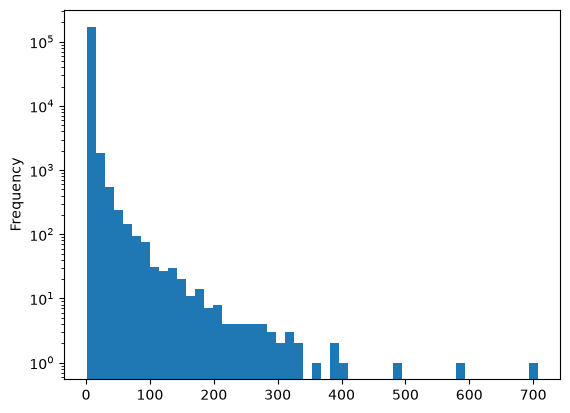

In [44]:
ratings_per_book = ratings_df["ISBN"].value_counts()
ratings_per_book.plot(kind="hist", bins=50, log=True)
ratings_per_book.describe()

#### Ratings per user

count    77805.000000
mean         5.563858
std         43.404724
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       8313.000000
Name: count, dtype: float64

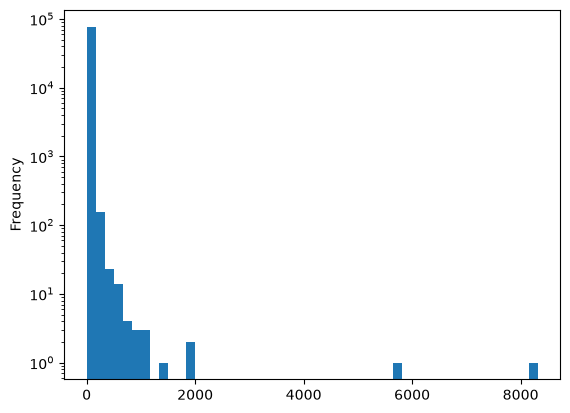

In [45]:
ratings_per_user = ratings_df["User-ID"].value_counts()
ratings_per_user.plot(kind="hist", bins=50, log=True)
ratings_per_user.describe()

#### Insight #1

Reviews per-user have higher deviation few super users with mega amounts of ratings but vast majority of users don't rank at all. For the reviews per book, most books also have no review but it is slightly more balanced. The base task also only gives one favourite book -> with a single book as favourite, and most users having no reviews finding similar users is difficult. The super users can actually benefit the item-item relations. **Item-based > User based.** I assume here I won't be using user age and location data as I don't think it can provide interesting recommandations (very surface level, generic).

In [46]:
print(f"Books count before: {ratings_df['ISBN'].nunique()}")
print(f"Users count before: {ratings_df['User-ID'].nunique()}")

# filter out books and users with few ratings
MIN_RATINGS_USER = 3
MIN_RATINGS_BOOK = 1
book_counts = ratings_df["ISBN"].value_counts()
user_counts = ratings_df["User-ID"].value_counts()


df = ratings_df.copy()
i = 0
while True:
    i += 1
    old_size = len(df)

    user_counts = df["User-ID"].value_counts()
    df = df[df["User-ID"].isin(user_counts[user_counts >= MIN_RATINGS_USER].index)]

    book_counts = df["ISBN"].value_counts()
    df = df[df["ISBN"].isin(book_counts[book_counts >= MIN_RATINGS_BOOK].index)]

    if len(df) == old_size:
        break

print(f"Iterations: {i}")

df_ratings_filtered = df.copy()

print(f"Books remaining: {df_ratings_filtered['ISBN'].nunique()}")
print(f"Users remaining: {df_ratings_filtered['User-ID'].nunique()}")

Books count before: 175779
Users count before: 77805
Iterations: 2
Books remaining: 158485
Users remaining: 22566


#### Insight #2

For item-item relations to work I need books to have ideally ratings from many users, and also users to give ratings to many books. The ladder needs to be atlest 2 to establish a relation. Since the data is so sparse I will only limit to at least 1 rating per book, but users for 2 ratings. Not ideal, some recommendations will be coincidental cause 1 users who rated this book also happened to rate this one, not necessirly cause they are similar.

#### Rated books

In [47]:
counts = df_ratings_filtered["ISBN"].value_counts()
result = books_df.set_index("ISBN").reindex(counts.index)[["title", "author"]]
result["num_ratings"] = counts.values
print(result.head())


print(f"Rated books without a title: {result["title"].isna().sum()}/{result.shape[0]}")

                                 title           author  num_ratings
ISBN                                                                
0316666343   The Lovely Bones: A Novel     Alice Sebold          497
0385504209           The Da Vinci Code        Dan Brown          381
0971880107                 Wild Animus     Rich Shapero          334
0142001740     The Secret Life of Bees    Sue Monk Kidd          302
0312278586  The Nanny Diaries: A Novel  Emma McLaughlin          296
Rated books without a title: 29105/158485


#### Insight #3

A lot of rated books don't have a title in the our books database. This could be resolved by merginng with another books dataset, or fetching manually upon retrieval.

## Collaborative filtering, item-based

In [48]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity

class RecomModelCF:
    def __init__(self, k, raw=False):
        self._k = k
        self._raw = raw

    def train(self, raitings_train_df):
        user_c = raitings_train_df["User-ID"].astype("category")
        book_c = raitings_train_df["ISBN"].astype("category")
        self.matrix = csr_matrix(
            (raitings_train_df["Book-Rating"], (user_c.cat.codes, book_c.cat.codes))
        )

        self.user_categories = user_c.cat.categories
        self.book_categories = book_c.cat.categories

        if self._raw:
            return
        
        self.U, self.sigma, self.Vt = svds(self.matrix, k=self._k)

    def recommend(self, isbn, n=10):
        if self._raw:
            return self._recommend_raw(isbn, n)
        
        book_vectors = self.Vt.T

        idx = self.book_categories.get_loc(isbn)

        sims = cosine_similarity(
            book_vectors[idx].reshape(1, -1),
            book_vectors
        )[0]

        top_idx = sims.argsort()[::-1][1:n+1]

        return pd.DataFrame({
            "ISBN": self.book_categories[top_idx],
            "score": sims[top_idx]
        })

    def _recommend_raw(self, isbn, n=10):
        idx = self.book_categories.get_loc(isbn)

        sims = cosine_similarity(
            self.matrix[:, idx].T,
            self.matrix.T
        )[0]

        top_idx = sims.argsort()[::-1][1:n+1]

        return pd.DataFrame({
            "ISBN": self.book_categories[top_idx],
            "score": sims[top_idx]
        })

#### Validation

The idea behind the validation process. 
- Get N users with >M 5+ ratings of books. This user likes these books.
- Then for each user hold out one book -> remove that user ranking on that book from train dataset.
- Per user: use the held out book to get recommendations on other books, the other books that user liked should be in the recommended books.
- Measure the recall rate. 

In [50]:
def validate(model, seed=42):
    MIN_LIKED_BOOKS = 20
    MAX_LIKED_BOOKS = 1000
    N_RECALL = 25
    TEST_USERS = 1000

    # get users
    user_ids = (
        df_ratings_filtered[df_ratings_filtered["Book-Rating"] >= 7]
        .groupby("User-ID")["ISBN"]
        .nunique()
    )
    user_ids = user_ids[(user_ids >= MIN_LIKED_BOOKS) & (user_ids <= MAX_LIKED_BOOKS)]
    user_ids = user_ids.sample(min(TEST_USERS, len(user_ids)), random_state=seed).index

    # get held out books per user
    liked = df_ratings_filtered[
        (df_ratings_filtered["Book-Rating"] >= 7) &
        (df_ratings_filtered["User-ID"].isin(user_ids))
    ]
    held_out = (
        liked
        .groupby("User-ID")
        .sample(n=1, random_state=seed)
    )
    non_heldout = liked.merge(
        held_out[["User-ID", "ISBN"]],
        on=["User-ID", "ISBN"],
        how="left",
        indicator=True
    )
    non_heldout = non_heldout[
        non_heldout["_merge"] == "left_only"
    ].drop(columns="_merge")

    # remove held out books from the train set
    train_df = df_ratings_filtered.merge(
        held_out[["User-ID", "ISBN"]],
        on=["User-ID", "ISBN"],
        how="left",
        indicator=True
    )
    train_df = train_df[
        train_df["_merge"] == "left_only"
    ].drop(columns="_merge")

    # train model
    model.train(train_df)

    hits = 0
    tries = 0

    for user_id, group in non_heldout.groupby("User-ID"):
        held_out_isbn = held_out.loc[
            held_out["User-ID"] == user_id, "ISBN"
        ].iloc[0]

        other_isbns = set(group["ISBN"])

        # skip if held out book is not in the model
        if held_out_isbn not in model.book_categories:
            continue

        recommended = model.recommend(
            isbn=held_out_isbn,
            n=N_RECALL
        )

        recommended_isbns = set(recommended["ISBN"])

        overlap = recommended_isbns & other_isbns

        tries += 1
        if overlap:
            hits += 1

    print(f"Hits: {hits}/{tries} [ {hits/tries} ]")

raw_model = RecomModelCF(k=0, raw=True)
print("raw model: ")
validate(raw_model, seed=42)

for k in [5, 7, 10, 12, 15, 20, 25]:
    model = RecomModelCF(k=k)
    print(f"k = {k}")
    validate(model, seed=42)

raw model: 
Hits: 94/741 [ 0.12685560053981107 ]
k = 5
Hits: 77/741 [ 0.1039136302294197 ]
k = 7
Hits: 98/741 [ 0.13225371120107962 ]
k = 10
Hits: 84/741 [ 0.11336032388663968 ]
k = 12
Hits: 92/741 [ 0.1241565452091768 ]
k = 15
Hits: 97/741 [ 0.13090418353576247 ]
k = 20


KeyboardInterrupt: 

#### Insight 5
The hit rate isn't too high, but that to be expected as it is just a proxy. It measures if the books that we know the user liked would be recommended to him. Where the real goal is to measure if the user would like the books that were recommended, which we can't measure directly. 

The SVD doesn't provide too much of the advantage. At k=15 it provides similar hit-rate, but is more memmory efficient.

In [51]:
# model
model_cf = RecomModelCF(k=15)
model_cf.train(df_ratings_filtered)

# book searcher
from rapidfuzz import process, fuzz
class BookSearcher:
    def __init__(self, df_ratings, df_books):
        rated_isbns = df_ratings["ISBN"].unique()

        self.books = df_books[
            df_books["ISBN"].isin(rated_isbns)
        ][["ISBN", "title", "author"]].dropna(
            subset=["title"]
        ).reset_index(drop=True)

    def find_by_title(self, title):
        results = process.extract(
            title,
            self.books["title"],
            scorer=fuzz.WRatio,
            limit=5
        )

        indices = [r[2] for r in results]

        return self.books.iloc[indices].assign(
            score=[r[1] for r in results]
        ).reset_index(drop=True)


In [56]:
SEARCH_TITLE = "Harry Potter"

bookSearcher = BookSearcher(df_ratings_filtered, df_books=books_df)

results = bookSearcher.find_by_title(SEARCH_TITLE)
print(results)

         ISBN                                              title  \
0  0767908473  The Sorcerer's Companion: A Guide to the Magic...   
1  059035342X  Harry Potter and the Sorcerer's Stone (Harry P...   
2  0590353403     Harry Potter and the Sorcerer's Stone (Book 1)   
3  0439064872   Harry Potter and the Chamber of Secrets (Book 2)   
4  0439136350  Harry Potter and the Prisoner of Azkaban (Book 3)   

               author  score  
0  ALLAN ZOLA KRONZEK   90.0  
1       J. K. Rowling   90.0  
2       J. K. Rowling   90.0  
3       J. K. Rowling   90.0  
4       J. K. Rowling   90.0  


In [60]:
SEARCH_ISBN = '0439136350'

recommendations = model.recommend(isbn=SEARCH_ISBN, n=10)

books = recommendations.merge(
    books_df[["ISBN", "title", "author"]],
    on="ISBN",
    how="left"
)

books = books[["title", "author"]]
print(books)

                                               title  \
0       Harry Potter and the Goblet of Fire (Book 4)   
1  The Soulforge (Dragonlance:  The Raistlin Chro...   
2              The Fermi Solution: Essays on Science   
3   Harry Potter and the Chamber of Secrets (Book 2)   
4            Ripening Seed (Noonday Press Book; 506)   
5  Through Hope and Despair: A Fan's Memories of ...   
6                         Simple Science Experiments   
7                                    Proteus a Novel   
8                        Dog Breed Handbooks: Poodle   
9  Skin Deep: Black Women &amp; White Women Write...   

                      author  
0              J. K. Rowling  
1              Margaret Weis  
2  Hans Christian Von Baeyer  
3              J. K. Rowling  
4                    Colette  
5           Dan Helpingstine  
6          Andrea McLoughlin  
7                Morris West  
8                Bruce Fogle  
9              Marita Golden  
